## [Dataset Titanic](https://www.kaggle.com/competitions/titanic/data)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

df_train = pd.read_csv('Data/titanic/train.csv')
df_test = pd.read_csv('Data/titanic/test.csv')
df_result = pd.read_csv('Data/titanic/gender_submission.csv')

df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Merging the test and result to be used later

In [2]:
df_test = pd.merge(df_test, df_result, how= 'left', on= 'PassengerId')

In [3]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


## Preprocess and EDA

In [4]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

We have a lot of missing values for `Cabin`, and some for `Age`. Let's investigate

In [5]:
df_train['Cabin'].unique()

<ArrowStringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

Let's try to use the Letter of the `Cabin` instead of the actual `Cabin`, so we can get more general features to work with, and fill the unknown with `U` for now

In [6]:
df_train['letter'] = df_train['Cabin'].str[0]

In [7]:
df_train['letter'] = df_train['letter'].fillna('U')
df_train['letter'].unique()

<ArrowStringArray>
['U', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']
Length: 9, dtype: str

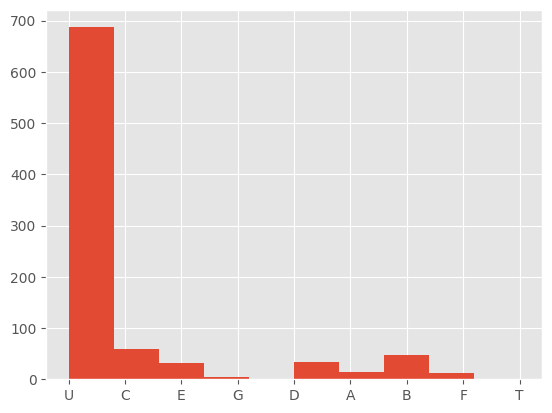

In [8]:
df_train['letter'].hist()
plt.show()

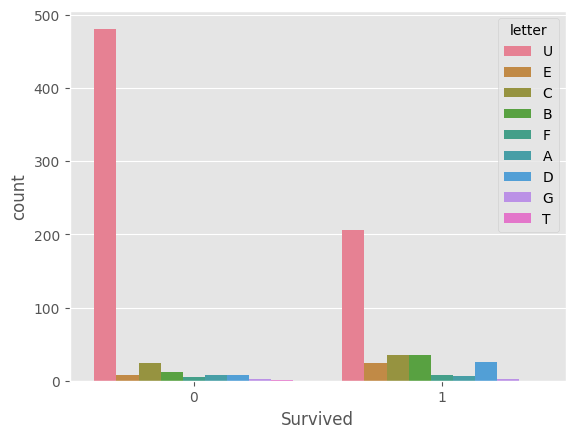

In [9]:
sns.countplot(df_train, hue = 'letter', x = 'Survived')

plt.show()

Let's work on the missing values for `Age`

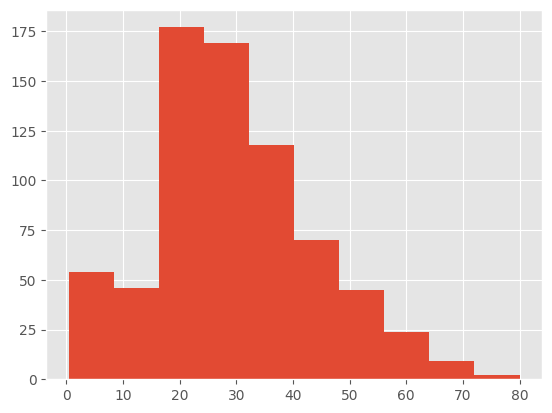

In [10]:
df_train['Age'].hist()
plt.show()

Let's investigate to see of the `Age` recording are missing based on passenger class, maybe the first class would have their age recorded, but the common passenger doesn't

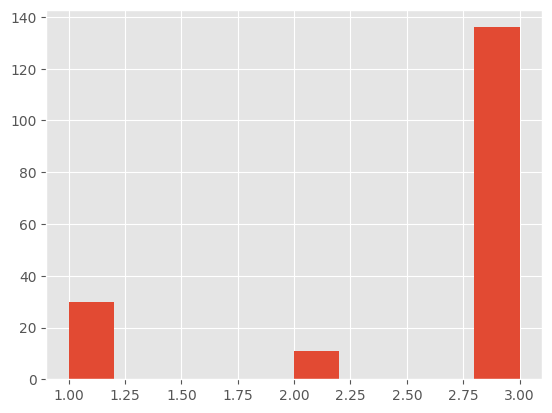

In [11]:
df = df_train
df[df['Age'].isnull()]['Pclass'].hist()
plt.show()

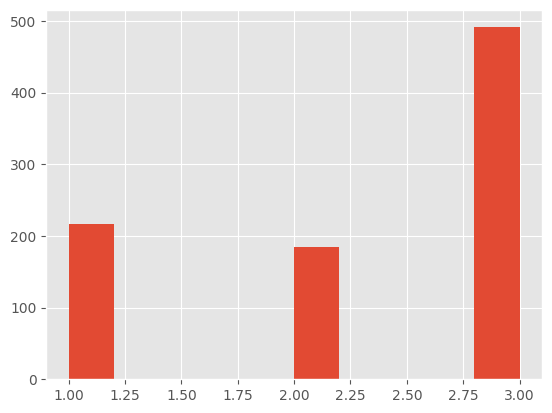

In [12]:
df['Pclass'].hist()
plt.show()

From these, we can deduct somewhat that most of the missing `Age` is in Class 3 - the `Common` class. Let's check on the family of these unknowns, and let's check if they have any family or children on board with them

In [13]:
# Compare proportions
print("Unknown age group:")
print(df[df['Age'].isnull()]['Parch'].value_counts(normalize=True))

print("\nKnown age group:")
print(df[df['Age'].notnull()]['Parch'].value_counts(normalize=True))

Unknown age group:
Parch
0    0.887006
2    0.067797
1    0.045198
Name: proportion, dtype: float64

Known age group:
Parch
0    0.729692
1    0.154062
2    0.095238
5    0.007003
3    0.007003
4    0.005602
6    0.001401
Name: proportion, dtype: float64


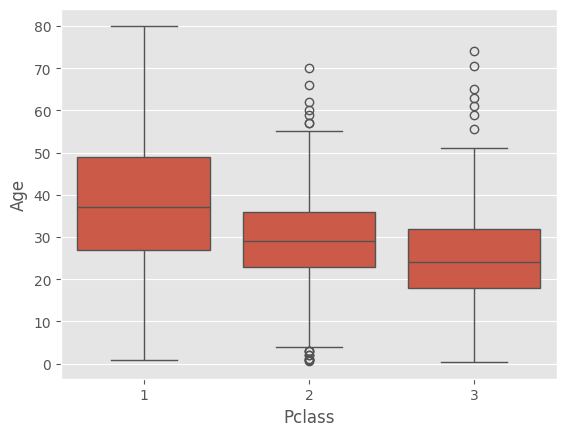

In [14]:
sns.boxplot(df, x = 'Pclass', y = 'Age')
plt.show()

So most of our *missing recorded Age* is in Passenger class 3, that has no children or family with them. Let's impute these missing values using the mean of the passenger class, and we can use the title within their name to help. For example `Miss` would be younger `Mrs` would be in the older,...

In [15]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
print(df['Title'].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [16]:
# Impute age using median of both Title and Pclass
df['Age'] = df.groupby(['Title', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

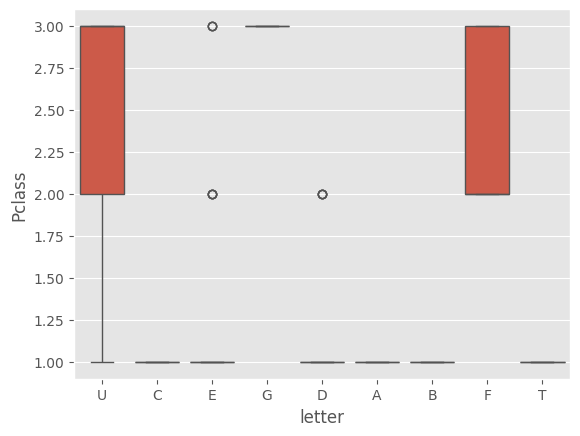

In [17]:
sns.boxplot(df, y = 'Pclass', x = 'letter')
plt.show()

In [18]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
letter           0
Title            0
dtype: int64

Let's drop the 2 missing in `Embarked`

In [19]:
df = df.dropna(subset=['Embarked'])


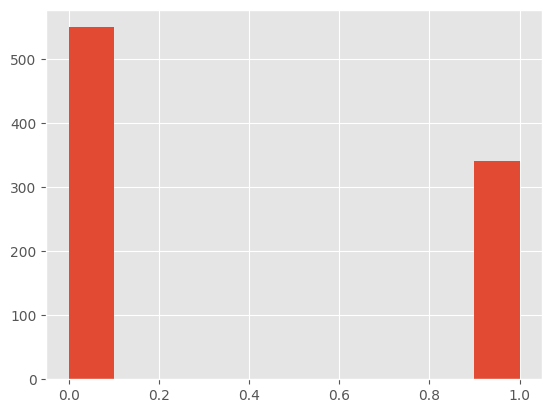

In [20]:
df['Survived'].hist()
plt.show()

Our `target` is slighly imbalanced, but it's fine. Let's move to encoding the rest of the features, and change the gender into binary flag

In [21]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value= -1)

df[['Embarked', 'Cabin_Letter', 'Title']] = oe.fit_transform(
    df[['Embarked','letter', "Title"]]
)

In [24]:
df['is_Male'] = (df['Sex'] == 'male').astype(int)

In [25]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'letter', 'Title',
       'Cabin_Letter', 'is_Male'],
      dtype='str')

In [34]:
df['Ticket'].unique()

<ArrowStringArray>
[       'A/5 21171',         'PC 17599', 'STON/O2. 3101282',
           '113803',           '373450',           '330877',
            '17463',           '349909',           '347742',
           '237736',
 ...
           '349212',           '349217',           '349257',
             '7552', 'C.A./SOTON 34068',  'SOTON/OQ 392076',
           '211536',           '112053',           '111369',
           '370376']
Length: 680, dtype: str

`Ticket` is quite complex, so we will leave them out for now

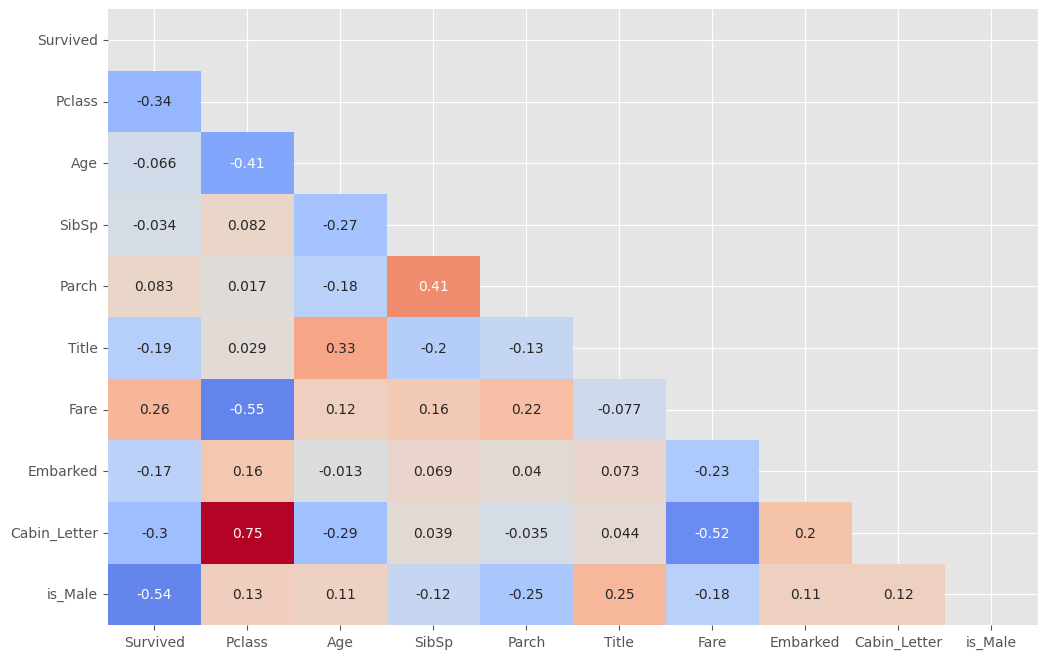

In [26]:
feature = [
    'Pclass', 'Age', 'SibSp', 'Parch', 
    'Title',
    'Fare', 'Embarked', 'Cabin_Letter', 'is_Male'
]

target = ['Survived']


matrix = df[target + feature].corr()

plt.figure(figsize= (12, 8))

mask = np.triu(np.ones_like(matrix, dtype= bool))

sns.heatmap(matrix, mask = mask, cmap = 'coolwarm',
            center = 0, annot = True, cbar =False)

plt.show()

`Gender` is one of the most correlated feature with `survived`. Looks like the story was true, of men staying behind, letting the woman and children get in the boat.

`Fare`, `Pclass`, `Cabin-Letter` also show that certain class would also have a better chance at making it out alive, hinting at the first class having a better chance to survive

### Making the same preprocessing steps we did with our test set

This is for in case we want to submit for the Kaggle competition

In [ ]:
# df_test['Title'] = df_test['Name'].str.extract(r',\s*([^\.]+)\.')
# df_test['letter'] = df_test['Cabin'].fillna('U').str[0]
# df_test['Age'] = df_test.groupby('Pclass')['Age'].transform(
#     lambda x: x.fillna(x.median())
# )

# df_test[['Embarked', 'Cabin_Letter', 'Title']] = oe.transform(
#     df_test[['Embarked','letter', 'Title']])

    
# df_test = df_test.dropna(subset= ['Fare'])

# df_test['is_Male'] = (df_test['Sex'] == 'male').astype(int)
# df_test.isnull().sum()


PassengerId       0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin           326
Embarked          0
Survived          0
Title             0
letter            0
Cabin_Letter      0
is_Male           0
dtype: int64

## Train test split and Model

We are using `XGB`, `Logistic Regression` and `Gradient Boosting`

In [ ]:
from sklearn.model_selection import train_test_split

X = df[feature].copy()
y = df[target].copy()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=8)
# X_test = df_test[feature].copy()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix


models = {
    'xgb' : XGBClassifier(
    n_estimators = 200,
    random_state = 8
),
    'base' : Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
]),
    'gradient' : GradientBoostingClassifier(
    n_estimators= 200,
    random_state= 8
)
    
}

for name, model in models.items():
    print(f'Training {name}')
    model.fit(X_train, y_train.values.ravel())

Training xgb
Training base
Training gradient


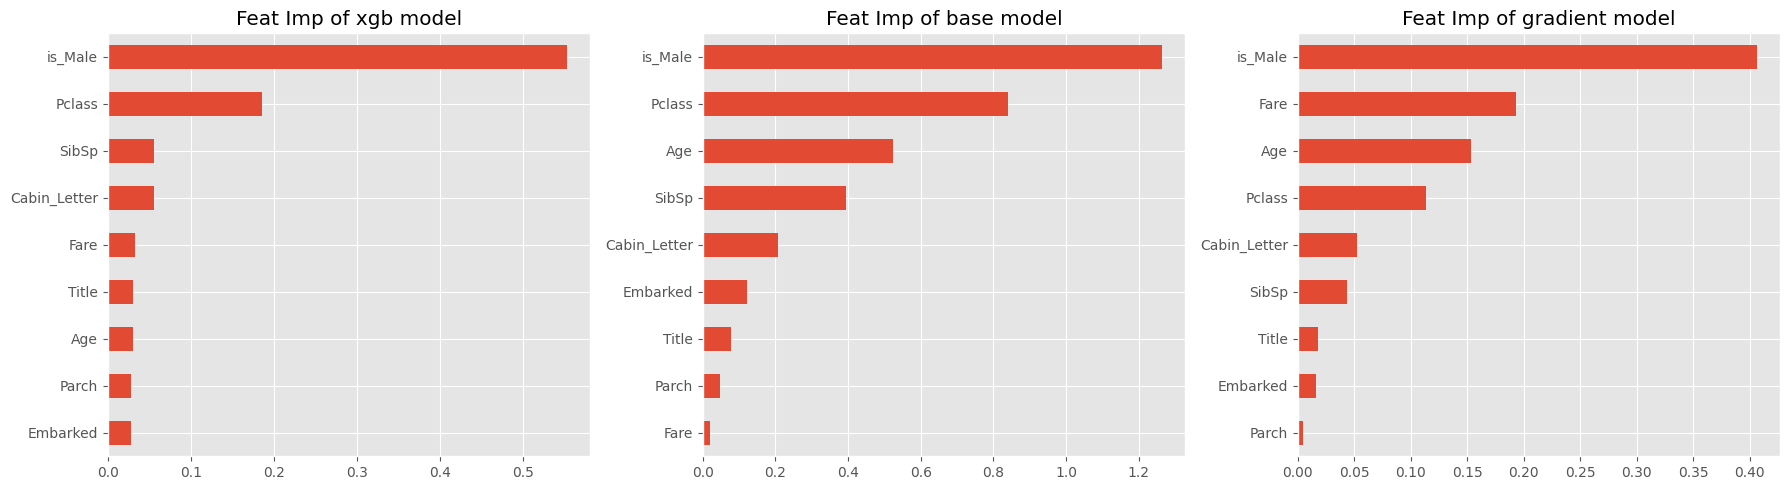

In [36]:
fig, axes = plt.subplots(1, len(models), figsize=(18, 5))
for ax, (name, model) in zip(axes, models.items()):
    if name == 'base':
        lr_model = model.named_steps['lr']
        importance = pd.Series(lr_model.coef_[0], index=X_train.columns).abs()
    else:
        importance = pd.Series(model.feature_importances_, index=X_train.columns)
    
    importance.sort_values().plot(kind='barh', ax=ax, title=f'Feat Imp of {name} model')

plt.tight_layout()
plt.show()

Model xgb
              precision    recall  f1-score   support

           0       0.89      0.83      0.86       108
           1       0.77      0.84      0.80        70

    accuracy                           0.84       178
   macro avg       0.83      0.84      0.83       178
weighted avg       0.84      0.84      0.84       178

Model base
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       108
           1       0.77      0.79      0.78        70

    accuracy                           0.83       178
   macro avg       0.82      0.82      0.82       178
weighted avg       0.83      0.83      0.83       178

Model gradient
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       108
           1       0.77      0.77      0.77        70

    accuracy                           0.82       178
   macro avg       0.81      0.81      0.81       178
weighted avg       0.82      0.82     

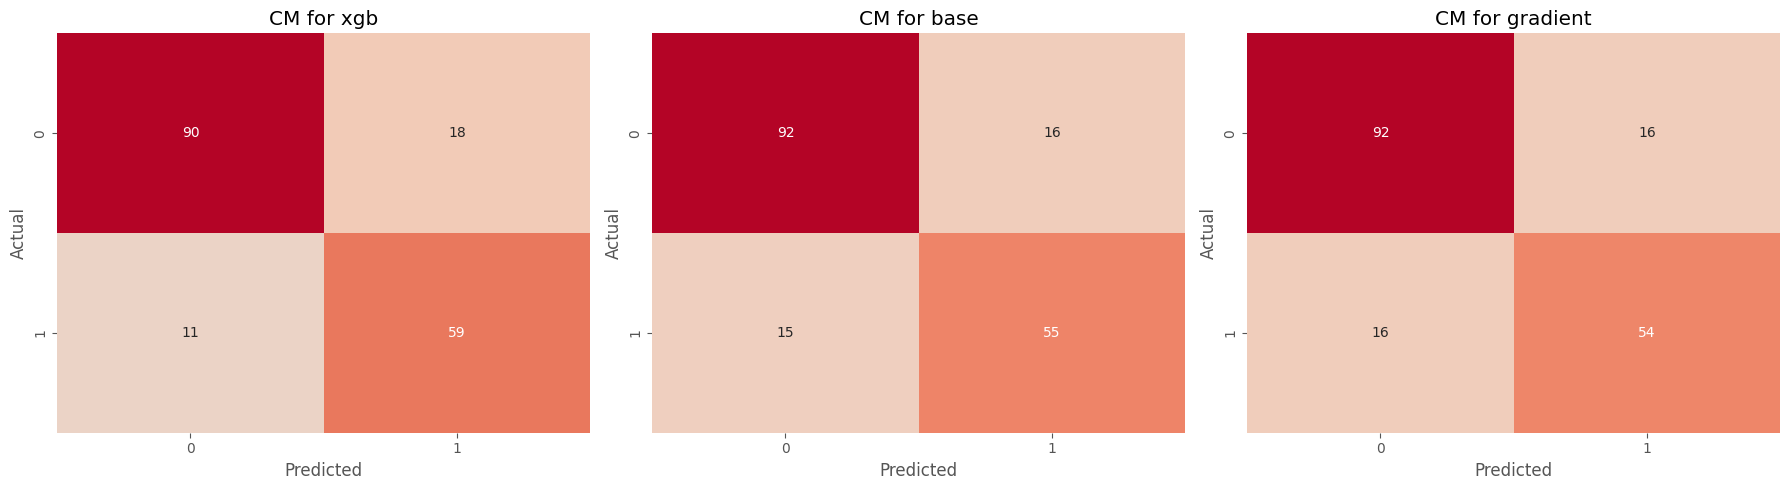

In [31]:
plt.figure(figsize=(18, 5))

for count, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_val)
    print(f'Model {name}')
    print(classification_report(y_true= y_val, y_pred= y_pred))

    cm = confusion_matrix(y_true= y_val, y_pred= y_pred)
    plt.subplot(1, 3, count + 1)
    sns.heatmap(cm, cmap = 'coolwarm', fmt = 'd', 
                center = 0, annot = True, cbar =False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'CM for {name}')

plt.tight_layout()
plt.show()

## Performance Analysis
### Insights

* **Sensitivity (Recall):** The XGBoost model is significantly better at identifying survivors. It only missed **11** survivors (False Negatives), whereas the Gradient Boosting model missed **16**.
* **Precision Stability:** All three models maintain a precision of $0.77$ for the positive class. This means that when any of these models predict someone survived, they are correct about 8 out of 10 time. 
* **Confusion Matrices:**
    * **XGBoost** shows the "cleanest" bottom-left quadrant (11 errors), indicating it understands the survival features better than the other two.
    * **Base** and **Gradient** models perform almost identically on the majority class (92 correct non-survivors) but struggle more than XGBoost when the actual label is $1$.

### TLDR

**XGBoost model** demonstrated the *strongest* predictive power. It achieved the highest overall accuracy ($84\%$) and the best balance between precision and recall for the minority class (survived = 1).